### 1. Conexion

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")
assert DATABASE_URL is not None, "No se encontró DATABASE_URL"

engine = create_engine(DATABASE_URL)

SCHEMA = "dm_enaho2025"

### 2. Leer Info de la base de datos 

In [2]:
query_columns = """
SELECT 
    table_name,
    column_name,
    ordinal_position
FROM information_schema.columns
WHERE table_schema = :schema
ORDER BY table_name, ordinal_position;
"""

query_pk = """
SELECT
    tc.table_name,
    kcu.column_name
FROM information_schema.table_constraints tc
JOIN information_schema.key_column_usage kcu
    ON tc.constraint_name = kcu.constraint_name
    AND tc.table_schema = kcu.table_schema
WHERE tc.table_schema = :schema
  AND tc.constraint_type = 'PRIMARY KEY'
ORDER BY tc.table_name, kcu.ordinal_position;
"""

query_fk = """
SELECT
    tc.table_name AS child_table,
    kcu.column_name AS child_column,
    ccu.table_name AS parent_table,
    ccu.column_name AS parent_column,
    tc.constraint_name
FROM information_schema.table_constraints tc
JOIN information_schema.key_column_usage kcu
    ON tc.constraint_name = kcu.constraint_name
    AND tc.table_schema = kcu.table_schema
JOIN information_schema.constraint_column_usage ccu
    ON ccu.constraint_name = tc.constraint_name
    AND ccu.table_schema = tc.table_schema
WHERE tc.table_schema = :schema
  AND tc.constraint_type = 'FOREIGN KEY'
ORDER BY child_table, constraint_name;
"""

columns_df = pd.read_sql(text(query_columns), engine, params={"schema": SCHEMA})
pk_df = pd.read_sql(text(query_pk), engine, params={"schema": SCHEMA})
fk_df = pd.read_sql(text(query_fk), engine, params={"schema": SCHEMA})

print("Columnas:", columns_df.shape)
print("Primary keys:", pk_df.shape)
print("Foreign keys:", fk_df.shape)

fk_df

Columnas: (129, 3)
Primary keys: (11, 2)
Foreign keys: (10, 5)


,child_table,child_column,parent_table,parent_column,constraint_name
0,fact_hogar_bienestar,agua_key,dim_agua,agua_key,fk_fact_agua
1,fact_hogar_bienestar,conectividad_key,dim_conectividad,conectividad_key,fk_fact_conectividad
2,fact_hogar_bienestar,energia_key,dim_energia,energia_key,fk_fact_energia
3,fact_hogar_bienestar,geografia_key,dim_geografia,geografia_key,fk_fact_geografia
4,fact_hogar_bienestar,habitabilidad_key,dim_habitabilidad,habitabilidad_key,fk_fact_habitabilidad
5,fact_hogar_bienestar,materiales_vivienda_key,dim_materiales_vivienda,materiales_vivienda_key,fk_fact_materiales_vivienda
6,fact_hogar_bienestar,saneamiento_key,dim_saneamiento,saneamiento_key,fk_fact_saneamiento
7,fact_hogar_bienestar,tenencia_propiedad_key,dim_tenencia_propiedad,tenencia_propiedad_key,fk_fact_tenencia_propiedad
8,fact_hogar_bienestar,tiempo_key,dim_tiempo,tiempo_key,fk_fact_tiempo
9,fact_hogar_bienestar,vivienda_key,dim_vivienda,vivienda_key,fk_fact_vivienda


### 3. Metadatos del diagrama

In [3]:
tables = sorted(columns_df["table_name"].unique())

pk_cols = (
    pk_df
    .groupby("table_name")["column_name"]
    .apply(set)
    .to_dict()
)

fk_cols = (
    fk_df
    .groupby("child_table")["child_column"]
    .apply(set)
    .to_dict()
)

columns_by_table = (
    columns_df
    .groupby("table_name")["column_name"]
    .apply(list)
    .to_dict()
)

tables

['dim_agua',
 'dim_conectividad',
 'dim_energia',
 'dim_geografia',
 'dim_habitabilidad',
 'dim_materiales_vivienda',
 'dim_saneamiento',
 'dim_tenencia_propiedad',
 'dim_tiempo',
 'dim_vivienda',
 'fact_hogar_bienestar']

### 4. Dibujar la tabla

In [4]:
# FUNCION PARA DIBUJAR LA TABLA 
def get_display_columns(table_name, columns, max_cols=12):
    """
    Reduce columnas para que el diagrama no se vuelva ilegible.
    En fact_hogar_bienestar prioriza keys e indicadores principales.
    """
    if table_name == "fact_hogar_bienestar":
        preferred = [
            "hogar_id",
            "tiempo_key",
            "geografia_key",
            "vivienda_key",
            "materiales_vivienda_key",
            "habitabilidad_key",
            "tenencia_propiedad_key",
            "agua_key",
            "saneamiento_key",
            "energia_key",
            "conectividad_key",
            "factor_expansion",
            "total_carencias_bienestar_habitacional",
            "brecha_multidimensional_ind"
        ]
        return [c for c in preferred if c in columns]

    if len(columns) <= max_cols:
        return columns

    return columns[:max_cols] + ["..."]


def draw_table(ax, table_name, x, y, columns, pk_cols, fk_cols):
    display_cols = get_display_columns(table_name, columns)

    lines = []
    table_pk = pk_cols.get(table_name, set())
    table_fk = fk_cols.get(table_name, set())

    for col in display_cols:
        if col == "...":
            lines.append("...")
            continue

        tags = []
        if col in table_pk:
            tags.append("PK")
        if col in table_fk:
            tags.append("FK")

        prefix = f"{'/'.join(tags)} " if tags else "   "
        lines.append(f"{prefix}{col}")

    width = 4.8
    line_height = 0.35
    height = 0.75 + line_height * len(lines)

    box = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=1.2,
        edgecolor="black",
        facecolor="white"
    )

    ax.add_patch(box)

    # Header
    ax.text(
        x,
        y + height / 2 - 0.25,
        table_name,
        ha="center",
        va="top",
        fontsize=9,
        fontweight="bold"
    )

    # Columnas
    start_y = y + height / 2 - 0.65
    for i, line in enumerate(lines):
        ax.text(
            x - width / 2 + 0.18,
            start_y - i * line_height,
            line,
            ha="left",
            va="top",
            fontsize=7
        )

    return {
        "x": x,
        "y": y,
        "width": width,
        "height": height
    }

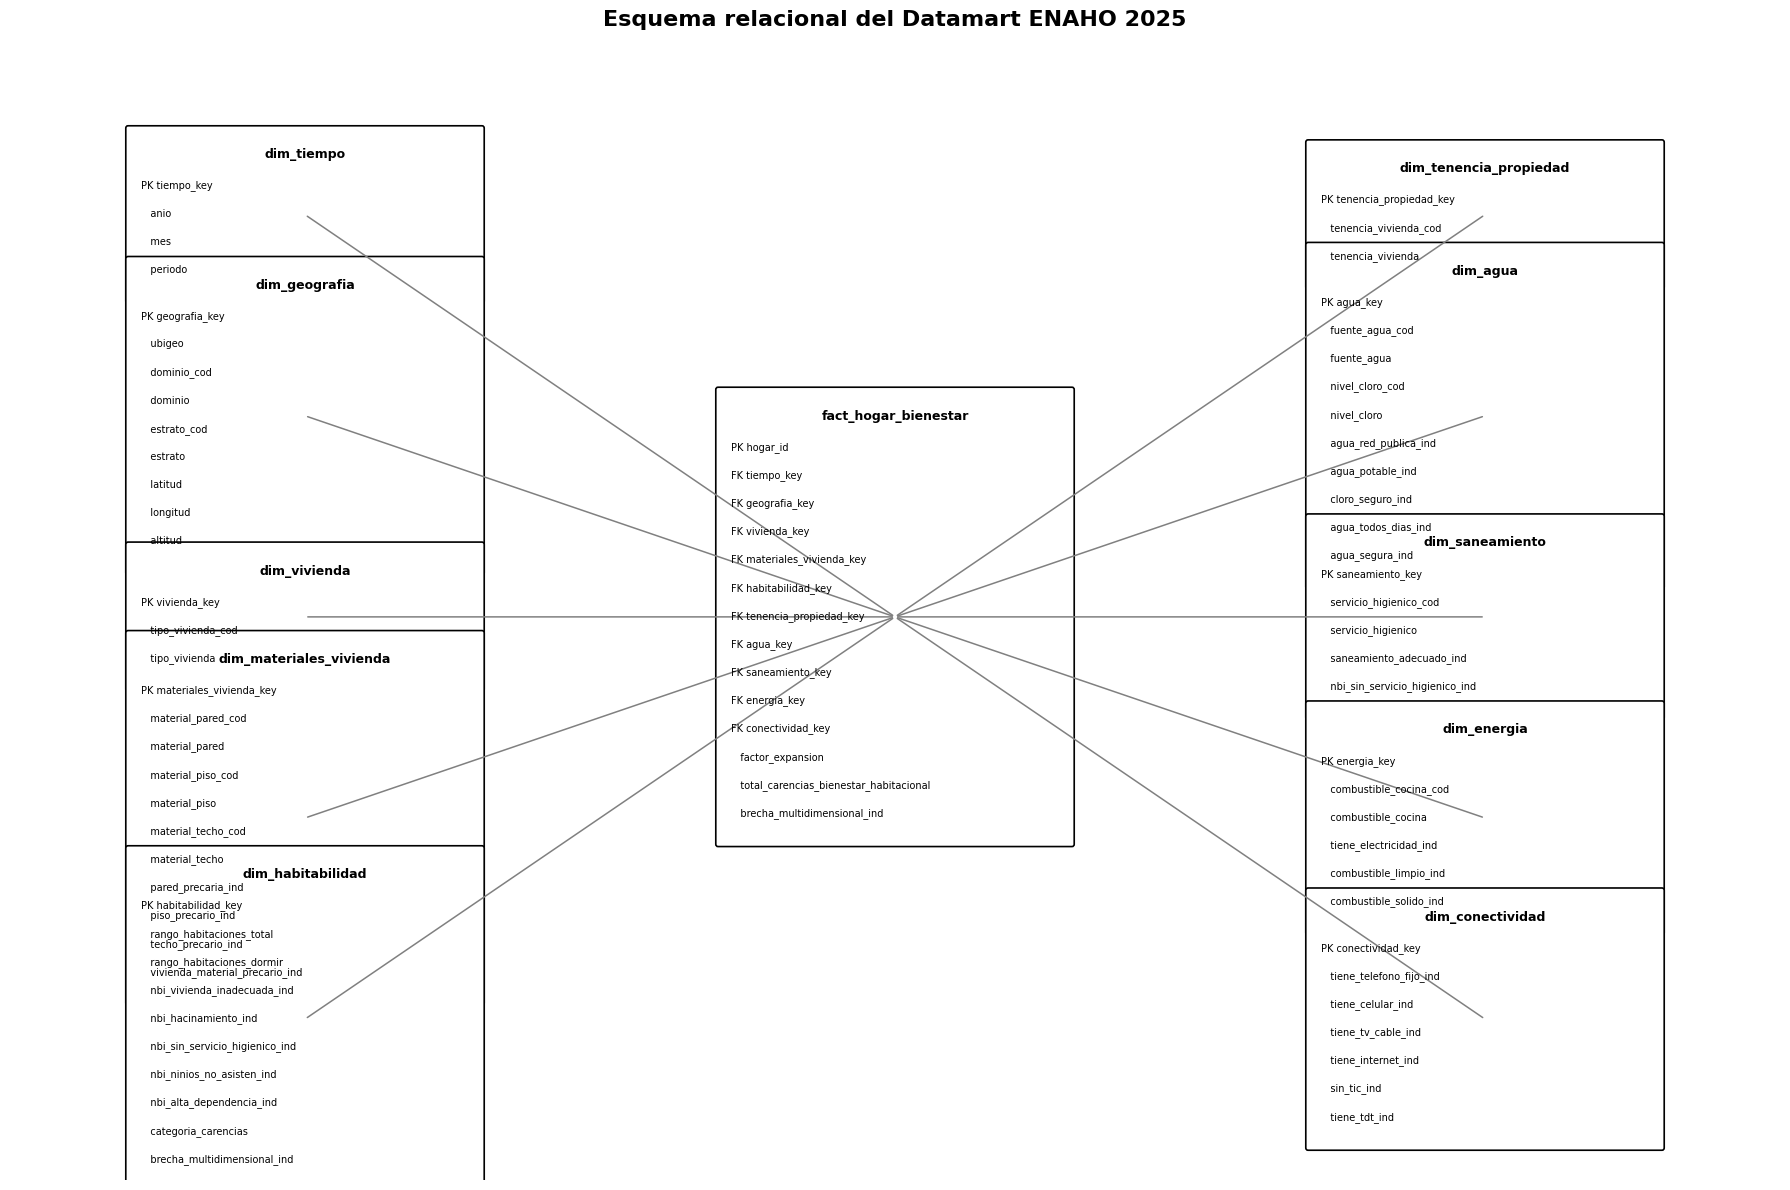

In [5]:
# DIBUJO DE LA TABLA

fact_table = "fact_hogar_bienestar"

dim_tables = [
    "dim_tiempo",
    "dim_geografia",
    "dim_vivienda",
    "dim_materiales_vivienda",
    "dim_habitabilidad",
    "dim_tenencia_propiedad",
    "dim_agua",
    "dim_saneamiento",
    "dim_energia",
    "dim_conectividad"
]

# Solo mantener tablas que existan realmente
dim_tables = [t for t in dim_tables if t in tables]

positions = {
    fact_table: (0, 0),
    "dim_tiempo": (-8, 5),
    "dim_geografia": (-8, 2.5),
    "dim_vivienda": (-8, 0),
    "dim_materiales_vivienda": (-8, -2.5),
    "dim_habitabilidad": (-8, -5),
    "dim_tenencia_propiedad": (8, 5),
    "dim_agua": (8, 2.5),
    "dim_saneamiento": (8, 0),
    "dim_energia": (8, -2.5),
    "dim_conectividad": (8, -5),
}

fig, ax = plt.subplots(figsize=(18, 12))
ax.set_axis_off()

drawn = {}

# Dibujar relaciones primero
for _, row in fk_df.iterrows():
    child = row["child_table"]
    parent = row["parent_table"]

    if child in positions and parent in positions:
        x1, y1 = positions[child]
        x2, y2 = positions[parent]

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="-",
                linewidth=1.1,
                color="gray"
            )
        )

# Dibujar tablas encima de las líneas
for table in [fact_table] + dim_tables:
    if table in positions:
        x, y = positions[table]
        drawn[table] = draw_table(
            ax=ax,
            table_name=table,
            x=x,
            y=y,
            columns=columns_by_table[table],
            pk_cols=pk_cols,
            fk_cols=fk_cols
        )

ax.set_xlim(-12, 12)
ax.set_ylim(-7, 7)

plt.title(
    "Esquema relacional del Datamart ENAHO 2025",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

In [6]:
# GUARDARLA

OUTPUT_DIR =  Path.cwd().parent / "data" / "outputs" / "diagrams"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PATH_ERD_PNG = OUTPUT_DIR / "erd_datamart_enaho2025.png"
PATH_ERD_PDF = OUTPUT_DIR / "erd_datamart_enaho2025.pdf"

fig.savefig(PATH_ERD_PNG, dpi=300, bbox_inches="tight")
fig.savefig(PATH_ERD_PDF, bbox_inches="tight")

print("Diagrama guardado en:")
print(PATH_ERD_PNG)
print(PATH_ERD_PDF)

Diagrama guardado en:
g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Business Intelligence\TrabajoFinal\repo\data\outputs\diagrams\erd_datamart_enaho2025.png
g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Business Intelligence\TrabajoFinal\repo\data\outputs\diagrams\erd_datamart_enaho2025.pdf


In [7]:
mermaid_lines = [
    "erDiagram"
]

for _, row in fk_df.iterrows():
    parent = row["parent_table"].upper()
    child = row["child_table"].upper()
    fk_col = row["child_column"]

    mermaid_lines.append(
        f"    {parent} ||--o{{ {child} : {fk_col}"
    )

mermaid_code = "\n".join(mermaid_lines)

print(mermaid_code)

erDiagram
    DIM_AGUA ||--o{ FACT_HOGAR_BIENESTAR : agua_key
    DIM_CONECTIVIDAD ||--o{ FACT_HOGAR_BIENESTAR : conectividad_key
    DIM_ENERGIA ||--o{ FACT_HOGAR_BIENESTAR : energia_key
    DIM_GEOGRAFIA ||--o{ FACT_HOGAR_BIENESTAR : geografia_key
    DIM_HABITABILIDAD ||--o{ FACT_HOGAR_BIENESTAR : habitabilidad_key
    DIM_MATERIALES_VIVIENDA ||--o{ FACT_HOGAR_BIENESTAR : materiales_vivienda_key
    DIM_SANEAMIENTO ||--o{ FACT_HOGAR_BIENESTAR : saneamiento_key
    DIM_TENENCIA_PROPIEDAD ||--o{ FACT_HOGAR_BIENESTAR : tenencia_propiedad_key
    DIM_TIEMPO ||--o{ FACT_HOGAR_BIENESTAR : tiempo_key
    DIM_VIVIENDA ||--o{ FACT_HOGAR_BIENESTAR : vivienda_key


In [8]:
PATH_MERMAID = OUTPUT_DIR / "erd_datamart_enaho2025.md"

with open(PATH_MERMAID, "w", encoding="utf-8") as f:
    f.write("# ERD Datamart ENAHO 2025\n\n")
    f.write("```mermaid\n")
    f.write(mermaid_code)
    f.write("\n```")

print(PATH_MERMAID)

g:\Mi unidad\UP - Ingeniería de la información\Semestre IX\Business Intelligence\TrabajoFinal\repo\data\outputs\diagrams\erd_datamart_enaho2025.md
